<div align="center">

# Preprocessing

</div>

# 1. Highpass fitler + Notch filter

In [11]:
import h5py
import numpy as np
import mne
import os

def filter_hdf5_file(h5_path, out_path, highpass=0.5, notch=60):

    with h5py.File(h5_path, "r") as f:
        signals = f["signals"][:]          # (ch, samples)
        fs = f["sampling_rate"][()]
        ch_names = [c.decode() for c in f["channel_names"][:]]
        seizures = f["seizure_intervals"][:]

    # -----------------------------
    # Create MNE object
    # -----------------------------
    info = mne.create_info(
        ch_names=ch_names,
        sfreq=fs,
        ch_types="eeg"
    )

    raw = mne.io.RawArray(signals, info, verbose=False)

    # -----------------------------
    # High-pass filter (0.5 Hz)
    # -----------------------------
    raw.filter(
        l_freq=highpass,
        h_freq=None,
        method="iir",
        iir_params=dict(order=4, ftype="butter"),
        phase="zero",
        verbose=False
    )

    # -----------------------------
    # Notch filter (60 Hz)
    # -----------------------------
    raw.notch_filter(
        freqs=notch,
        method="iir",
        phase="zero",
        iir_params=dict(order=4, ftype="butter"),
        verbose=False
    )
    



    filtered = raw.get_data()

    # -----------------------------
    # Save filtered HDF5
    # -----------------------------
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    with h5py.File(out_path, "w") as f:
        f.create_dataset("signals", data=filtered, compression="gzip")
        f.create_dataset("sampling_rate", data=fs)
        f.create_dataset(
            "channel_names",
            data=np.array(ch_names, dtype="S")
        )
        f.create_dataset("seizure_intervals", data=seizures)

    print(f"Saved filtered → {out_path}")

In [ ]:
import glob
import os

input_dir = "../Dataset_hdf5_clean"
output_dir = "../Dataset_hdf5_filtered"

# Create output directory if not exists
os.makedirs(output_dir, exist_ok=True)

files = glob.glob(input_dir + "/**/*.h5", recursive=True)

if not files:
    print(f"No .h5 files found in {input_dir}")
else:
    print(f"Found {len(files)} files. Processing...")
    for f in files:
        out = f.replace("Dataset_hdf5", "Dataset_hdf5_filtered")
        
        # Create output subdirectory
        os.makedirs(os.path.dirname(out), exist_ok=True)
        
        try:
            filter_hdf5_file(f, out)
            print(f"✓ Filtered: {os.path.basename(f)}")
        except Exception as e:
            print(f"✗ Error filtering {f}: {e}")

## 1.1 Plot before and after

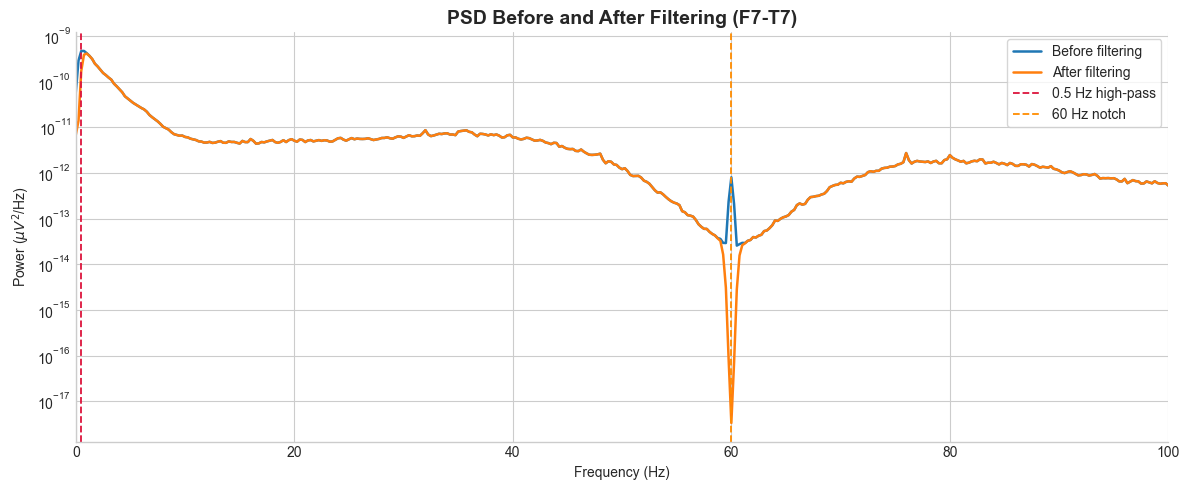

In [16]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# HDF5 loader
# -----------------------------
def load_h5(path):

    with h5py.File(path, "r") as f:

        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]

    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]

    return signals, fs, ch_names

# -----------------------------
# Load files
# -----------------------------
raw_signals, fs, ch_names = load_h5(
    "../Dataset_hdf5//chb01/chb01_06.h5"
)

filtered_signals, _, _ = load_h5(
    "../Dataset_hdf5_filtered_clean//chb01/chb01_06.h5"
)

# -----------------------------
# Select channel
# -----------------------------
channel_name = "F7-T7"
ch_idx = ch_names.index(channel_name)

raw_signal = raw_signals[ch_idx]
filtered_signal = filtered_signals[ch_idx]

# -----------------------------
# PSD using Welch
# -----------------------------
freqs_raw, psd_raw = welch(
    raw_signal,
    fs=fs,
    nperseg=int(fs * 4)
)

freqs_filt, psd_filt = welch(
    filtered_signal,
    fs=fs,
    nperseg=int(fs * 4)
)

# -----------------------------
# Plot PSD comparison
# -----------------------------
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 5))

# Raw PSD
ax.semilogy(
    freqs_raw,
    psd_raw,
    label="Before filtering",
    linewidth=1.8
)

# Filtered PSD
ax.semilogy(
    freqs_filt,
    psd_filt,
    label="After filtering",
    linewidth=1.8
)

# Filter markers
ax.axvline(
    0.5,
    color="crimson",
    linestyle="--",
    linewidth=1.3,
    label="0.5 Hz high-pass"
)

ax.axvline(
    60,
    color="darkorange",
    linestyle="--",
    linewidth=1.3,
    label="60 Hz notch"
)

# Formatting
ax.set_xlim(0, 100)

ax.set_title(
    f"PSD Before and After Filtering ({channel_name})",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"Power ($\mu V^2$/Hz)")

ax.legend(frameon=True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()